In [1]:
# tumor_identification_metrics.ipynb - plot metrics (F1 score etc) of tumor identification.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/tumor_identification/subclone'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/tumor_identification/subclone/analysis/tumor_identification'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.startswith('1r')])
run_id_list

['1r1n2t']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    metric_fn = os.path.join(run_dir, 'base/tumor_identification/2_metric/metrics.tsv')
    if not os.path.exists(metric_fn):
        print("[W] file '%s' does not exist!" % metric_fn)
        continue
    df = pd.read_csv(metric_fn, sep = '\t')
    df['run_id'] = run_id
    if dat is None:
        dat = df
    else:
        dat = pd.concat([dat, df], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat

processing '1r1n2t' ...
dat shape: (25, 4)


,tool,metric,value,run_id
0,CalicoST,accuracy,0.684703,1r1n2t
1,CopyKAT,accuracy,0.665999,1r1n2t
2,inferCNV,accuracy,0.665999,1r1n2t
3,Numbat,accuracy,0.995992,1r1n2t
4,XClone,accuracy,0.653307,1r1n2t
5,CalicoST,precision,0.939900,1r1n2t
6,CopyKAT,precision,1.000000,1r1n2t
7,inferCNV,precision,1.000000,1r1n2t
8,Numbat,precision,0.996997,1r1n2t
9,XClone,precision,0.985830,1r1n2t


In [6]:
dat['tool'] = dat['tool'].replace({'CopyKat':'CopyKAT', 'inferCNV':'InferCNV'})
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.684703,1r1n2t
1,CopyKAT,accuracy,0.665999,1r1n2t
2,InferCNV,accuracy,0.665999,1r1n2t
3,Numbat,accuracy,0.995992,1r1n2t
4,XClone,accuracy,0.653307,1r1n2t
5,CalicoST,precision,0.939900,1r1n2t
6,CopyKAT,precision,1.000000,1r1n2t
7,InferCNV,precision,1.000000,1r1n2t
8,Numbat,precision,0.996997,1r1n2t
9,XClone,precision,0.985830,1r1n2t


In [7]:
metric_fn = os.path.join(out_dir, 'tumor_identification.metrics.tsv')
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [8]:
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.684703,1r1n2t
1,CopyKAT,accuracy,0.665999,1r1n2t
2,InferCNV,accuracy,0.665999,1r1n2t
3,Numbat,accuracy,0.995992,1r1n2t
4,XClone,accuracy,0.653307,1r1n2t
5,CalicoST,precision,0.939900,1r1n2t
6,CopyKAT,precision,1.000000,1r1n2t
7,InferCNV,precision,1.000000,1r1n2t
8,Numbat,precision,0.996997,1r1n2t
9,XClone,precision,0.985830,1r1n2t


## Plot

In [9]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.684703,1r1n2t
1,CopyKAT,accuracy,0.665999,1r1n2t
2,InferCNV,accuracy,0.665999,1r1n2t
3,Numbat,accuracy,0.995992,1r1n2t
4,XClone,accuracy,0.653307,1r1n2t
5,CalicoST,precision,0.939900,1r1n2t
6,CopyKAT,precision,1.000000,1r1n2t
7,InferCNV,precision,1.000000,1r1n2t
8,Numbat,precision,0.996997,1r1n2t
9,XClone,precision,0.985830,1r1n2t


In [10]:
dat['run_id_raw'] = dat['run_id']
dat_raw = dat.copy()
dat

,tool,metric,value,run_id,run_id_raw
0,CalicoST,accuracy,0.684703,1r1n2t,1r1n2t
1,CopyKAT,accuracy,0.665999,1r1n2t,1r1n2t
2,InferCNV,accuracy,0.665999,1r1n2t,1r1n2t
3,Numbat,accuracy,0.995992,1r1n2t,1r1n2t
4,XClone,accuracy,0.653307,1r1n2t,1r1n2t
5,CalicoST,precision,0.939900,1r1n2t,1r1n2t
6,CopyKAT,precision,1.000000,1r1n2t,1r1n2t
7,InferCNV,precision,1.000000,1r1n2t,1r1n2t
8,Numbat,precision,0.996997,1r1n2t,1r1n2t
9,XClone,precision,0.985830,1r1n2t,1r1n2t


In [11]:
dat = dat[['tool', 'metric', 'run_id', 'value']].pivot(
    index = ['run_id', 'tool'],
    columns = 'metric',
    values = 'value'
).reset_index()
dat

metric,run_id,tool,ARI,F1,accuracy,precision,recall
0,1r1n2t,CalicoST,0.132088,0.704631,0.684703,0.939900,0.563564
1,1r1n2t,CopyKAT,0.098528,0.666222,0.665999,1.000000,0.499499
2,1r1n2t,InferCNV,0.098528,0.666222,0.665999,1.000000,0.499499
3,1r1n2t,Numbat,0.983821,0.996997,0.995992,0.996997,0.996997
4,1r1n2t,XClone,0.081638,0.652378,0.653307,0.985830,0.487487


In [12]:
def plot_metrics(df, metric, metric_label, figsize = (9, 5), fontsize = 10, ymin = 0):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'F1'.
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    # Extract unique groups
    tool_order = ['InferCNV', 'CopyKAT', 'Numbat', 'XClone', 'CalicoST']
    df['tool'] = pd.Categorical(df['tool'], categories = tool_order, ordered = True)
    df = df.sort_values('tool')

    # Colors
    tool_colors = [plt.cm.tab10(i % 10) for i in range(len(tool_order))]

    # Create plot
    fig, ax = plt.subplots(figsize = figsize)

    # Draw stacked bars
    y_star = 0.05
    bar_width = 0.6
    j = 0
    for i, tool in enumerate(tool_order):
        has_output = True
        if tool in df['tool'].to_numpy():
            h = df[metric].iloc[j]
            if h < 0:
                has_output = False
            j += 1
        else:
            has_output = False
        x_pos = i
        if has_output:
            ax.bar(
                x_pos,
                h,
                bottom = 0,
                width = bar_width,
                #color = tool_colors[i],
                color = tool_colors[0],
                edgecolor = None,
                linewidth = 0.5,
                label = tool
            )
        else:
            ax.text(
                x_pos, y_star,
                '*', 
                ha = 'center', va = 'top',
                fontsize = fontsize - 1,
                color = 'black',
                weight = 'bold'
            )

    # Main axis styling
    ax.set_xticks(range(len(tool_order)))
    ax.set_xticklabels(tool_order, rotation = 45, ha = 'right', rotation_mode = 'anchor')
    ax.set_xlim(None, len(tool_order)-1+bar_width/2+0.01)
    ax.set_xlabel(None)
    ax.set_ylabel(metric_label, fontsize = fontsize + 1)
    ax.set_ylim(ymin, 1.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    return fig, ax

### Plot F1

In [13]:
metric = 'F1'
metric_label = 'F1 score'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,F1,run_id
0,CalicoST,0.704631,1r1n2t
1,CopyKAT,0.666222,1r1n2t
2,InferCNV,0.666222,1r1n2t
3,Numbat,0.996997,1r1n2t
4,XClone,0.652378,1r1n2t


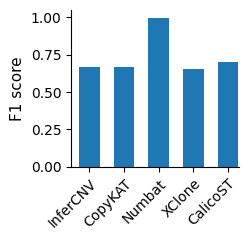

In [14]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.5, 2.5), fontsize = 10)

In [15]:
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot accuracy

In [16]:
metric = 'accuracy'
metric_label = 'Accuracy'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,accuracy,run_id
0,CalicoST,0.684703,1r1n2t
1,CopyKAT,0.665999,1r1n2t
2,InferCNV,0.665999,1r1n2t
3,Numbat,0.995992,1r1n2t
4,XClone,0.653307,1r1n2t


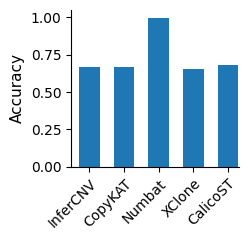

In [17]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.5, 2.5), fontsize = 10)

In [18]:
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot precision

In [19]:
metric = 'precision'
metric_label = 'Precision'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,precision,run_id
0,CalicoST,0.939900,1r1n2t
1,CopyKAT,1.000000,1r1n2t
2,InferCNV,1.000000,1r1n2t
3,Numbat,0.996997,1r1n2t
4,XClone,0.985830,1r1n2t


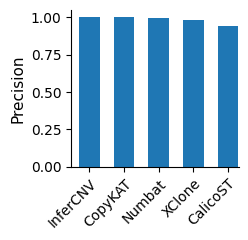

In [20]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.5, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot recall

In [21]:
metric = 'recall'
metric_label = 'Recall'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,recall,run_id
0,CalicoST,0.563564,1r1n2t
1,CopyKAT,0.499499,1r1n2t
2,InferCNV,0.499499,1r1n2t
3,Numbat,0.996997,1r1n2t
4,XClone,0.487487,1r1n2t


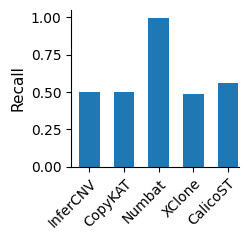

In [22]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.5, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot ARI

In [23]:
metric = 'ARI'
metric_label = 'ARI'    # Adjusted Rand Index
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,ARI,run_id
0,CalicoST,0.132088,1r1n2t
1,CopyKAT,0.098528,1r1n2t
2,InferCNV,0.098528,1r1n2t
3,Numbat,0.983821,1r1n2t
4,XClone,0.081638,1r1n2t


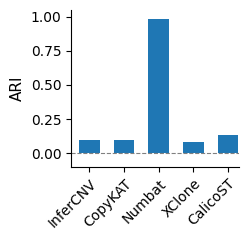

In [24]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.5, 2.5), fontsize = 10, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.png' % metric)
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')